## Imports

This section loads the required libraries.

In [2]:
from pathlib import Path
from collections import OrderedDict

import matplotlib.pyplot as plt
from PIL import Image
import random

## Dataset paths

This section defines the dataset directories.

In [3]:
data_dir = Path("../data/raw/fer2013")

train_dir = data_dir / "train"
test_dir = data_dir / "test"

print("Train path:", train_dir.resolve())
print("Test path:", test_dir.resolve())

print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

Train path: C:\Users\harsh\facial-emotion-recognition-cv\data\raw\fer2013\train
Test path: C:\Users\harsh\facial-emotion-recognition-cv\data\raw\fer2013\test
Train exists: True
Test exists: True


## Class folders

This section lists the emotion classes.

In [4]:
train_classes = sorted([f.name for f in train_dir.iterdir() if f.is_dir()])
test_classes = sorted([f.name for f in test_dir.iterdir() if f.is_dir()])

print("Train classes:", train_classes)
print("Test classes:", test_classes)

Train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Class image counts

This section counts images in each class.

In [5]:
train_counts = OrderedDict()
test_counts = OrderedDict()

for cls in train_classes:
    train_counts[cls] = len(list((train_dir / cls).glob("*")))

for cls in test_classes:
    test_counts[cls] = len(list((test_dir / cls).glob("*")))

print("Training images:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nTest images:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

Training images:
angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171

Test images:
angry: 958
disgust: 111
fear: 1024
happy: 1774
neutral: 1233
sad: 1247
surprise: 831


## Sample images

This section displays sample images from different classes.

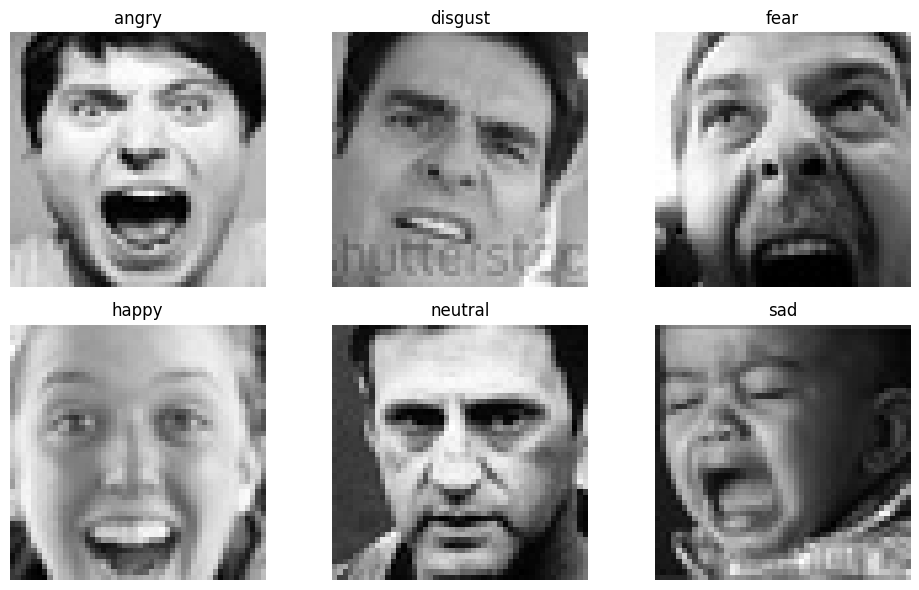

In [6]:
sample_images = []

for cls in train_classes:
    images = list((train_dir / cls).glob("*"))
    if images:
        sample_images.append(random.choice(images))

plt.figure(figsize=(10, 6))

for i, img_path in enumerate(sample_images[:6]):
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(img_path.parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observation

The dataset contains seven emotion classes with grayscale face images of size 48×48. The class distribution is imbalanced, with disgust having much fewer samples than the other classes. Some classes also appear visually similar.

## Report note

FER2013 is used for supervised facial emotion classification. The dataset is organised into training and test folders with seven classes: angry, disgust, fear, happy, neutral, sad, and surprise. The dataset is imbalanced, which is considered during evaluation.